In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import tcr_embeddings_path, mhc_embeddings_path, peptide_embeddings_path, all_relations_path, train_path, val_path, test_path, CMV_dataset_path, CNN_tcr_embeddings_path
import pickle
import dhg
import dhg.nn as dnn
from dhg.nn import GCNConv
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.parametrizations import orthogonal
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from typing import List, Tuple, Optional, Union
import import_ipynb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import average_precision_score
from Evaluator import evaluate
# import Hypergraph as HGipynb


/home/tarnickil/.conda/envs/mgr_thesis/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open(tcr_embeddings_path, "rb") as f:
    tcr_embbedings = pickle.load(f)

with open(mhc_embeddings_path, "rb") as f:
    mhc_embbedings = pickle.load(f)

with open(peptide_embeddings_path, "rb") as f:
    peptide_embbedings = pickle.load(f)

with open(CNN_tcr_embeddings_path, "rb") as f:
    cnn_tcr_embeddings = pickle.load(f)

In [3]:
with open(train_path, "rb") as f:
    Train_data = pickle.load(f)

with open(val_path, "rb") as f:
    Val_data = pickle.load(f)

with open(test_path, "rb") as f: 
    Test_data = pickle.load(f)

with open(CMV_dataset_path, "rb") as f:
    cmv_dataset = pickle.load(f)

In [ ]:
map_dict = {"Non-binding":0, "Binding":1}
Train_data["Binding"] = Train_data["Binding"].replace(map_dict)
tcr_embbedings.rename({"Name":"TCR_name"}, axis=1, inplace=True)
cnn_tcr_embeddings.rename({"Name":"TCR_name"}, axis=1, inplace=True)
vals = Train_data["Binding"].value_counts().values
pos_prob = vals[1]/vals[0]
vals


array([76782,  8806])

In [5]:
tr = Train_data["Binding"].value_counts().values
v = Val_data["Binding"].value_counts().values
ts = Test_data["Binding"].value_counts().values
print((tr[1]/tr[0]),(v[1]/v[0]),(ts[1]/ts[0]))

0.1146883384126488 0.11806689368848253 0.11790352930377714


In [6]:
tr = Train_data["HLA_MHC"].value_counts().values
v = Val_data["HLA_MHC"].value_counts().values
ts = Test_data["HLA_MHC"].value_counts().values
print((tr[1]/tr[0]),(v[1]/v[0]),(ts[1]/ts[0]))

1.0 1.0 1.0


In [7]:
np.sum(cmv_dataset[["TCR_name", "HLA_MHC"]].groupby("TCR_name").agg("count")["HLA_MHC"].values)/2

np.float64(66957.0)

In [8]:
cmv_dataset["TCR_name"].drop_duplicates().shape

(66957,)

In [10]:
cmv_dataset

,Name,pMHC,CDR3a,CDR3b,Epitop,TCR_name,HLA_MHC,Binding,Count
0,A0301_KLGGALQAK_IE-1_CMV_binder_TCR_1,A0301_KLGGALQAK_IE-1_CMV_binder,CAVEALTGGGNKLTF,CASSAYTSGPKEQYF,IE-1_CMV_binder,TCR_1,HLA-A0301,0,1
1,A0301_KLGGALQAK_IE-1_CMV_binder_TCR_10,A0301_KLGGALQAK_IE-1_CMV_binder,CAVRDKNSGYSTLTF,CASTSADGYGYTF,IE-1_CMV_binder,TCR_10,HLA-A0301,0,1
2,A0301_KLGGALQAK_IE-1_CMV_binder_TCR_100,A0301_KLGGALQAK_IE-1_CMV_binder,CAVRDDDYKLSF,CASRFLAGGSHEQYF,IE-1_CMV_binder,TCR_100,HLA-A0301,0,4
3,A0301_KLGGALQAK_IE-1_CMV_binder_TCR_1000,A0301_KLGGALQAK_IE-1_CMV_binder,CAVRGYSSASKIIF,CASSHTEETGELFF,IE-1_CMV_binder,TCR_1000,HLA-A0301,0,1
4,A0301_KLGGALQAK_IE-1_CMV_binder_TCR_10000,A0301_KLGGALQAK_IE-1_CMV_binder,CALSDPLPLNAGKSTF,CASSERGGTVNEQFF,IE-1_CMV_binder,TCR_10000,HLA-A0301,0,1
...,...,...,...,...,...,...,...,...,...
133909,A2402_AYAQKIFKI_IE-1_CMV_binder_TCR_9995,A2402_AYAQKIFKI_IE-1_CMV_binder,CALSLDNYGQNFVF,CASSETSLYEQYF,IE-1_CMV_binder,TCR_9995,HLA-A2402,0,1
133910,A2402_AYAQKIFKI_IE-1_CMV_binder_TCR_9996,A2402_AYAQKIFKI_IE-1_CMV_binder,CALSPVNYGQNFVF,CASRDTDTQYF,IE-1_CMV_binder,TCR_9996,HLA-A2402,0,1
133911,A2402_AYAQKIFKI_IE-1_CMV_binder_TCR_9997,A2402_AYAQKIFKI_IE-1_CMV_binder,CALSRIDNYGQNFVF,CASSQEVAGGIGDEQFF,IE-1_CMV_binder,TCR_9997,HLA-A2402,0,1
133912,A2402_AYAQKIFKI_IE-1_CMV_binder_TCR_9998,A2402_AYAQKIFKI_IE-1_CMV_binder,CALSVDNYGQNFVF,CASSYSGTGGGLAGELFF,IE-1_CMV_binder,TCR_9998,HLA-A2402,0,1


##### Podejście trywialne KNN search

In [ ]:
alpha_pd = pd.DataFrame(np.stack(tcr_embbedings[["Embeddings_alpha"]].values.flatten()))
alpha_pd["index"] = alpha_pd.index
beta_pd = pd.DataFrame(np.stack(tcr_embbedings[["Embeddings_beta"]].values.flatten()))
beta_pd["index"] = beta_pd.index
alpha_beta_pd=pd.merge(
    left=alpha_pd,
    right=beta_pd,
    how="left",
    on="index"
)
alpha_beta_pd["TCR_name"] = tcr_embbedings["TCR_name"].values
alpha_beta_pd.drop("index", axis=1, inplace=True)
# alpha_beta_pd.loc[[1,2,4,5,8,9], alpha_beta_pd.columns != 'TCR_name']

In [ ]:
df_primary = alpha_beta_pd.copy()
df_primary['MHC'] = 1

# Kopia z etykietą 0 (obiekt powiązany)
df_secondary = alpha_beta_pd.copy()
df_secondary['MHC'] = 0

# Złączenie — każdy Name pojawia się teraz dwa razy
df_final = pd.concat([df_primary, df_secondary], ignore_index=True)

# Posortowanie żeby pary były obok siebie (opcjonalne)
alpha_beta_pd = df_final.sort_values('TCR_name').reset_index(drop=True)

In [ ]:
y_all = cmv_dataset[["TCR_name", "Binding"]].sort_values("TCR_name")["Binding"].values
alpha_beta_pd["Y"] = y_all

In [ ]:
train_tcr = Train_data["TCR_name"].values
train = alpha_beta_pd[alpha_beta_pd["TCR_name"].isin(train_tcr)]

val_tcr = Val_data["TCR_name"].values
val = alpha_beta_pd[alpha_beta_pd["TCR_name"].isin(val_tcr)]

test_tcr = Test_data["TCR_name"].values
test = alpha_beta_pd[alpha_beta_pd["TCR_name"].isin(test_tcr)]

In [ ]:
y_train = train["Y"]
X_train = train.drop(["TCR_name", "Y"], axis=1)
cols = X_train.columns

y_val = val["Y"]
X_val = val.drop(["TCR_name", "Y"], axis=1)

y_test = test["Y"]
X_test = test.drop(["TCR_name", "Y"], axis=1)

In [ ]:
# k_n = [3,5,7,10,15,20]
# scores = []
# for i in k_n:
#     neigh = KNeighborsClassifier(n_neighbors=i)
#     neigh.fit(X_train, y_train)
#     score = neigh.score(X_val, y_val)
#     scores.append(score)
# scores

In [ ]:
val.drop("TCR_name", axis=1)

,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,...,632_y,633_y,634_y,635_y,636_y,637_y,638_y,639_y,MHC,Y
2,-0.201929,0.049425,0.206612,-0.081626,-0.053623,-0.061955,-0.002744,-0.203753,-0.048203,0.229586,...,-0.494951,0.139283,0.079517,0.172255,-0.009847,0.111069,-0.194751,-0.150091,0,0
3,-0.201929,0.049425,0.206612,-0.081626,-0.053623,-0.061955,-0.002744,-0.203753,-0.048203,0.229586,...,-0.494951,0.139283,0.079517,0.172255,-0.009847,0.111069,-0.194751,-0.150091,1,0
14,-0.152050,0.081268,0.168313,0.079005,-0.130905,-0.032233,0.012234,-0.292088,-0.146505,0.226391,...,-0.677936,0.093986,0.023747,0.276774,-0.036944,0.167166,-0.241916,0.010101,1,0
15,-0.152050,0.081268,0.168313,0.079005,-0.130905,-0.032233,0.012234,-0.292088,-0.146505,0.226391,...,-0.677936,0.093986,0.023747,0.276774,-0.036944,0.167166,-0.241916,0.010101,0,0
22,-0.098361,-0.013027,0.220042,-0.057471,-0.156810,-0.223375,-0.089655,-0.355338,-0.145888,0.242064,...,-0.577656,0.267920,-0.026529,0.130968,0.029693,0.224968,-0.231332,-0.089629,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133903,-0.235436,0.062681,0.114185,-0.077035,-0.150239,-0.055287,-0.060263,-0.272487,-0.056544,0.152774,...,-0.559869,0.184060,0.031083,0.235603,-0.091265,0.266980,-0.251243,-0.089081,0,0
133906,-0.204261,0.045306,0.150312,-0.047754,-0.211003,-0.054112,-0.042135,-0.241131,-0.020137,0.204271,...,-0.374970,0.159849,0.033976,0.101145,-0.094091,0.068756,-0.267614,-0.189768,1,0
133907,-0.204261,0.045306,0.150312,-0.047754,-0.211003,-0.054112,-0.042135,-0.241131,-0.020137,0.204271,...,-0.374970,0.159849,0.033976,0.101145,-0.094091,0.068756,-0.267614,-0.189768,0,0
133910,-0.189794,0.097396,0.148116,-0.043843,-0.190446,-0.038102,-0.073917,-0.271919,-0.030521,0.157625,...,-0.574920,0.177954,0.012060,0.191979,0.024860,0.060256,-0.274789,-0.064665,0,0


In [ ]:
neigh = KNeighborsClassifier(n_neighbors=10, metric="cosine")
neigh.fit(X_train, y_train)
# evaluate_model(model=neigh, val_df=val.drop("TCR_name", axis=1), test_df=test.drop("TCR_name", axis=1), feature_cols=cols, mhc_col="MHC", model_name="KNN", label_col="Y")

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'cosine'
,metric_params,None
,n_jobs,None


In [ ]:
neigh.score(X_test, y_test)

0.8943262993677642

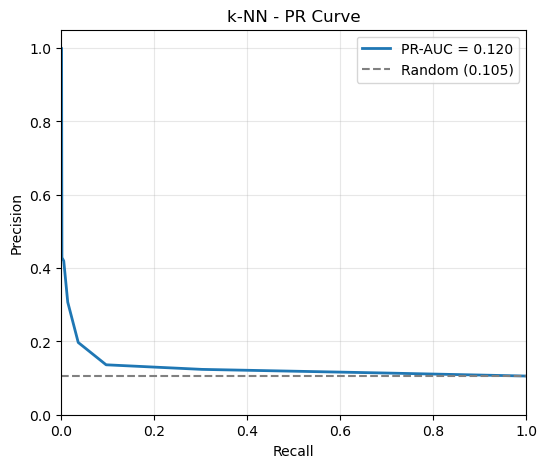

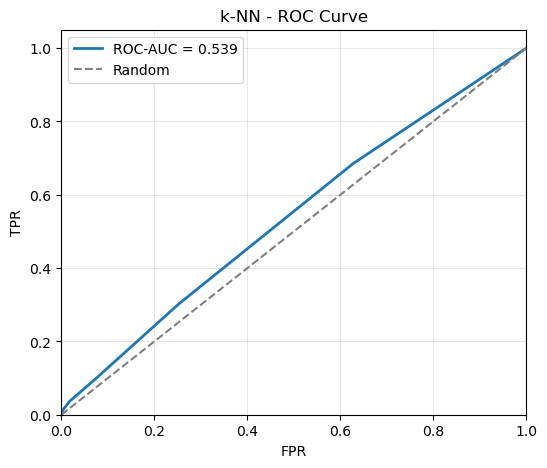

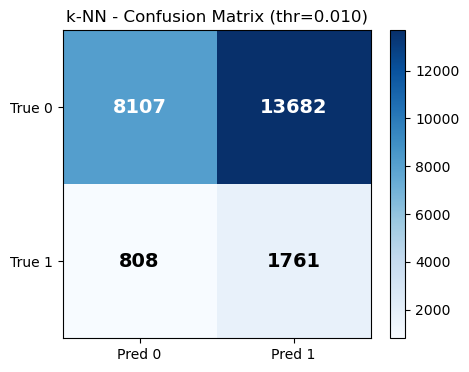

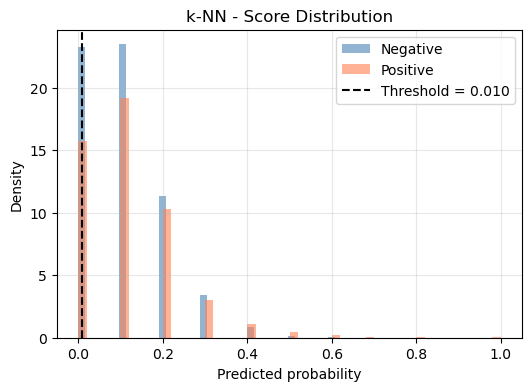

In [ ]:
p_test_knn = neigh.predict_proba(X_test)[:, 1]
p_val_knn = neigh.predict_proba(X_val)[:, 1]
results_knn = evaluate(y_test, p_test_knn, y_val, p_val_knn, model_name="k-NN", save_plots_dir="Wyniki_KNN")

##### Podejścei MLP baseline

In [ ]:
class model_MLP(nn.Module):
        
    '''Wejście: konkatenacja [ESM2(α), ESM2(β), MHC_embedding] (np. 2560 + 16 = 2576
        wymiarów).'''

    def __init__(self, in_dim, hidden_dim, name = "model_MLP"):
        super().__init__()

        self.projection_layers = nn.Sequential(
            orthogonal(nn.Linear(in_dim, hidden_dim)),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        self.prediction_layers = nn.Sequential(
            orthogonal(nn.Linear(hidden_dim, (hidden_dim//2))),
            nn.GELU(),
            nn.Dropout(0.3),
            orthogonal(nn.Linear((hidden_dim//2), (hidden_dim//4))),
            nn.GELU(),
            nn.Dropout(0.3),
            orthogonal(nn.Linear((hidden_dim//4), 1))
        )
    
    def forward(self, X):
        X_ = self.projection_layers(X)
        X_ = self.prediction_layers(X_)
        return X_
        

##### Podejście baseline CNN

In [ ]:
class TCRCMVConvNet(nn.Module):
    def __init__(self, esm_dim=640, n_filters=16, kernel_sizes=[3,5,7,9],
                 n_mhc=2, mhc_emb_dim=16, dropout=0.3):
        super().__init__()

        self.name = "TCRCMVConvNet"
        
        # Per-chain convolutions
        self.alpha_convs = nn.ModuleList([
            nn.Conv1d(esm_dim, n_filters, k, padding=(k-1)//2)
            for k in kernel_sizes
        ])
        self.beta_convs = nn.ModuleList([
            nn.Conv1d(esm_dim, n_filters, k, padding=(k-1)//2)
            for k in kernel_sizes
        ])
        
        # MHC embedding
        self.mhc_embedding = nn.Embedding(n_mhc, mhc_emb_dim)
        
        # Klasyfikator
        n_chain_features = n_filters * len(kernel_sizes)  # 16 * 4 = 64
        combined_dim = 2 * n_chain_features + mhc_emb_dim  # 64 + 64 + 16 = 144
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )
        
        # self._init_weights()
    
    def encode_chain(self, x, convs):
        # x: [B, esm_dim, L]
        conv_outs = [F.gelu(conv(x)) for conv in convs]  # [B, n_filters, L]
        concat = torch.cat(conv_outs, dim=1)  # [B, n_filters*K, L]
        pooled = concat.max(dim=2).values  # [B, n_filters*K]
        return pooled
    
    def forward(self, alpha, beta, mhc_id):
        # alpha, beta: [B, esm_dim, L]  (po transpose)
        # mhc_id: [B] (long tensor z indeksami MHC)
        
        alpha_feat = self.encode_chain(alpha, self.alpha_convs)
        beta_feat = self.encode_chain(beta, self.beta_convs)
        mhc_feat = self.mhc_embedding(mhc_id)
        
        combined = torch.cat([alpha_feat, beta_feat, mhc_feat], dim=1)
        logits = self.classifier(combined)  # [B, 1]
        return logits.squeeze(-1)  # [B]
        

##### Podejście Grafowe GNN

In [ ]:
class TCRCMVGraphNet1(nn.Module):
    def __init__(
        self,
        d_esm2=1280,
        d_mhc_onehot=2,
        d_target_flag=4,
        d_hidden=256,
        n_gcn_layers=4,
        dropout_node=0.3,
        dropout_gcn=0.4,
        dropout_classifier=0.3,
    ):
        super().__init__()
        self.name = "TCRCMVGraphNet"
        self.d_hidden = d_hidden
        self.n_gcn_layers = n_gcn_layers
        
        # TCR projection
        self.tcr_projection = nn.Sequential(
            nn.Linear(d_esm2, d_hidden),
            nn.LayerNorm(d_hidden),
        )
        
        # Node fusion (po konkatenacji z MHC i target flag)
        self.node_fusion = nn.Sequential(
            nn.Linear(d_hidden + d_mhc_onehot + d_target_flag, d_hidden),
            nn.GELU(),
            nn.Dropout(dropout_node),
        )
        
        # Stos warstw GCN
        self.gcn_layers = nn.ModuleList([
            GCNConv(d_hidden, d_hidden, use_bn=False, drop_rate=0.0)
            for _ in range(n_gcn_layers)
        ])
        self.gcn_dropouts = nn.ModuleList([
            nn.Dropout(dropout_gcn)
            for _ in range(n_gcn_layers)
        ])
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(d_hidden, d_hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout_classifier),
            nn.Linear(d_hidden // 2, 1),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        # Ostatnia warstwa classifier: gain=1.0 (przed sigmoid w loss)
        nn.init.orthogonal_(self.classifier[-1].weight, gain=1.0)
    
    def forward(self, X_features, graph, target_idx, d_esm2=1280, d_mhc=2):
        # X_features: [N, d_esm2 + d_mhc + d_target_flag] = [N, 1286]
        # graph: dhg.Graph
        # target_idx: scalar (lub batch [B])
        
        # Rozdzielenie cech
        X_esm2 = X_features[:, :d_esm2]
        X_mhc = X_features[:, d_esm2:d_esm2 + d_mhc]
        X_target = X_features[:, d_esm2 + d_mhc:]
        
        # TCR projection
        h_esm2 = self.tcr_projection(X_esm2)  # [N, d_hidden]
        
        # Node fusion
        h_concat = torch.cat([h_esm2, X_mhc, X_target], dim=1)  # [N, d_hidden + 6]
        h_0 = self.node_fusion(h_concat)  # [N, d_hidden]
        
        # GCN stack z residualami
        all_layers = [h_0]
        h = h_0
        for gcn_layer, dropout in zip(self.gcn_layers, self.gcn_dropouts):
            h_new = gcn_layer(h, graph)
            h_new = F.gelu(h_new)
            h_new = dropout(h_new)
            h = h_new + h  # residual
            all_layers.append(h)
        
        # JK aggregation (max-pool po warstwach)
        h_stacked = torch.stack(all_layers, dim=0)  # [n_layers+1, N, d_hidden]
        h_jk = h_stacked.max(dim=0).values  # [N, d_hidden]
        
        # Target node selection
        h_target = h_jk[target_idx]  # [d_hidden] lub [B, d_hidden]
        
        # Classifier
        logits = self.classifier(h_target)  # [1] lub [B, 1]
        return logits.squeeze(-1)  # [] lub [B]
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
class TCRCMVGraphNet2(nn.Module):
    def __init__(
        self,
        d_esm2=1280,
        d_mhc_onehot=2,
        d_target_flag=4,
        d_hidden=256,
        n_gcn_layers=3,
        dropout_node=0.3,
        dropout_gcn=0.3,
        dropout_classifier=0.3,
    ):
        super().__init__()
        self.name = "TCRCMVGraphNet"
        self.d_hidden = d_hidden
        self.n_gcn_layers = n_gcn_layers
        
        # TCR projection
        self.tcr_projection = nn.Sequential(
            nn.Linear(d_esm2, d_hidden),
            nn.LayerNorm(d_hidden),
        )
        
        # Node fusion (po konkatenacji z MHC i target flag)
        self.node_fusion = nn.Sequential(
            nn.Linear(d_hidden + d_mhc_onehot + d_target_flag, d_hidden),
            nn.GELU(),
            nn.Dropout(dropout_node),
        )
        
        # Stos warstw GCN
        self.gcn_layers = nn.ModuleList([
            GCNConv(d_hidden, d_hidden, use_bn=False, drop_rate=0.0)
            # GATConv(d_hidden, d_hidden, drop_rate=0, use_bn=True)
            # UWAGA: GATConv powoduje crash (segfault) w DHG 0.9.6 na CUDA:
            #   - atten_drop_rate=0.5 domyślnie → NaN gradienty → illegal memory access
            #   - use_bn=True: _init_weights() nie inicjalizuje wewnętrznych warstw DHG
            for _ in range(n_gcn_layers)
        ])
        self.gcn_dropouts = nn.ModuleList([
            nn.Dropout(dropout_gcn)
            for _ in range(n_gcn_layers)
        ])
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(d_hidden, d_hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout_classifier),
            nn.Linear(d_hidden // 2, 1),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        # Ostatnia warstwa classifier: gain=1.0 (przed sigmoid w loss)
        nn.init.orthogonal_(self.classifier[-1].weight, gain=1.0)
    
    def forward(self, X_features, graph, target_idx, d_esm2=1280, d_mhc=2):
        # X_features: [N, d_esm2 + d_mhc + d_target_flag] = [N, 1286]
        # graph: dhg.Graph
        # target_idx: scalar (lub batch [B])
        
        # Rozdzielenie cech
        X_esm2 = X_features[:, :d_esm2]
        X_mhc = X_features[:, d_esm2:d_esm2 + d_mhc]
        X_target = X_features[:, d_esm2 + d_mhc:]
        
        # TCR projection
        h_esm2 = self.tcr_projection(X_esm2)  # [N, d_hidden]
        
        # Node fusion
        h_concat = torch.cat([h_esm2, X_mhc, X_target], dim=1)  # [N, d_hidden + 6]
        h_0 = self.node_fusion(h_concat)  # [N, d_hidden]
        
        # GCN stack z residualami
        all_layers = [h_0]
        h = h_0
        for gcn_layer, dropout in zip(self.gcn_layers, self.gcn_dropouts):
            h_new = gcn_layer(h, graph)
            h_new = F.gelu(h_new)
            h_new = dropout(h_new)
            h = h_new + h  # residual
            all_layers.append(h)
        
        # JK aggregation (max-pool po warstwach)
        h_stacked = torch.stack(all_layers, dim=0)  # [n_layers+1, N, d_hidden]
        h_jk = h_stacked.max(dim=0).values  # [N, d_hidden]
        
        # Target node selection
        h_target = h_jk[target_idx]  # [d_hidden] lub [B, d_hidden]
        
        # Classifier
        logits = self.classifier(h_target)  # [1] lub [B, 1]
        return logits.squeeze(-1)  # [] lub [B]

##### DataLoader'y

In [ ]:
##############################################################
#----------------------!!! DATA LOADERS !!!-------------------
##############################################################
# ===========================================================================
# 1. MLP: cechy tabelaryczne (ESM2 mean-pooled + one-hot MHC)
# ===========================================================================
class MLPDataset(Dataset):
    """Cechy: konkatenacja [ESM2(alpha), ESM2(beta), one-hot MHC]."""
 
    def __init__(self, df, X_TCR, mhc_to_id):
        self.df = df.reset_index(drop=True)
        self.n_mhc = len(mhc_to_id)
        self.mhc_to_id = mhc_to_id
 
        # Pre-load embeddingów do słownika dla szybkiego dostępu
        X_indexed = X_TCR.set_index("TCR_name")
        self.embeddings_dict = {}
        for name in self.df["TCR_name"].unique():
            row = X_indexed.loc[name]
            alpha = np.array(row["Embeddings_alpha"], dtype=np.float32)
            beta = np.array(row["Embeddings_beta"], dtype=np.float32)
            self.embeddings_dict[name] = np.concatenate([alpha, beta])
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        esm = self.embeddings_dict[row["TCR_name"]]
 
        mhc_onehot = np.zeros(self.n_mhc, dtype=np.float32)
        mhc_onehot[self.mhc_to_id[row["HLA_MHC"]]] = 1.0
 
        features = np.concatenate([esm, mhc_onehot])
        label = float(row["Binding"])
 
        return torch.from_numpy(features), torch.tensor(label, dtype=torch.float32)
 
 
def get_mlp_loader(df, X_TCR, mhc_to_id, batch_size=256, shuffle=False,
                   class_balanced=False, num_workers=4, pin_memory=True):
    """
    Zwraca DataLoader dla MLP.
 
    class_balanced=True dla train (50/50 pos/neg).
    shuffle=False dla val/test.
    """
    dataset = MLPDataset(df, X_TCR, mhc_to_id)
 
    sampler = None
    if class_balanced:
        labels = df["Binding"].values.astype(int)
        class_counts = np.bincount(labels)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
        )
        shuffle = False
 
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
# ===========================================================================
# 2. CNN: per-residue embeddingi z paddingiem
# ===========================================================================
class CNNDataset(Dataset):
    """
    Per-residue embeddingi dla alpha i beta chain.
    Padding wykonuje collate_cnn (per batch).
    """
 
    def __init__(self, df, X_TCR, mhc_to_id):
        """
        X_TCR : DataFrame z kolumnami:
            TCR_name, Embeddings_alpha, Embeddings_beta.
            Każda komórka *_perres to array [L, d_esm] (różne L per TCR).
        """
        self.df = df.reset_index(drop=True)
        self.mhc_to_id = mhc_to_id
 
        X_indexed = X_TCR.set_index("TCR_name")
        self.embeddings_dict = {}
        for name in self.df["TCR_name"].unique():
            row = X_indexed.loc[name]
            alpha = np.array(row["Embeddings_alpha"], dtype=np.float32)
            beta = np.array(row["Embeddings_beta"], dtype=np.float32)
            self.embeddings_dict[name] = (alpha, beta)
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        alpha, beta = self.embeddings_dict[row["TCR_name"]]
        mhc_id = self.mhc_to_id[row["HLA_MHC"]]
        label = float(row["Binding"])
 
        return (
            torch.from_numpy(alpha),
            torch.from_numpy(beta),
            torch.tensor(mhc_id, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32),
        )
 
 
def collate_cnn(batch):
    """Padding alpha i beta do max długości w batchu. Konwencja Conv1d: [B, C, L]."""
    alphas = [item[0] for item in batch]
    betas = [item[1] for item in batch]
    mhc_ids = torch.stack([item[2] for item in batch])
    labels = torch.stack([item[3] for item in batch])
 
    L_max_a = max(a.shape[0] for a in alphas)
    L_max_b = max(b.shape[0] for b in betas)
    d_esm = alphas[0].shape[1]
 
    alpha_padded = torch.zeros(len(batch), L_max_a, d_esm)
    beta_padded = torch.zeros(len(batch), L_max_b, d_esm)
 
    for i, (a, b) in enumerate(zip(alphas, betas)):
        alpha_padded[i, : a.shape[0]] = a
        beta_padded[i, : b.shape[0]] = b
 
    alpha_padded = alpha_padded.transpose(1, 2)  # [B, d_esm, L_a]
    beta_padded = beta_padded.transpose(1, 2)    # [B, d_esm, L_b]
 
    return alpha_padded, beta_padded, mhc_ids, labels
 
 
def get_cnn_loader(df, X_TCR, mhc_to_id, batch_size=128, shuffle=False,
                   class_balanced=False, num_workers=4, pin_memory=True):
    """Zwraca DataLoader dla CNN."""
    dataset = CNNDataset(df, X_TCR, mhc_to_id)
 
    sampler = None
    if class_balanced:
        labels = df["Binding"].values.astype(int)
        class_counts = np.bincount(labels)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
        )
        shuffle = False
 
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=pin_memory,
        collate_fn=collate_cnn,
    )
# ===========================================================================
# 3. GNN: pre-computed podgrafy w plikach .pt
# ===========================================================================
class GNNDataset(Dataset):
    """
    Każdy plik .pt to jeden podgraf z polami:
    X, edge_list, e_weight, target_idx, target_label (i opcjonalnie inne).
    """
 
    def __init__(self, subgraph_dir, pattern="*.pt"):
        """
        subgraph_dir : ścieżka do katalogu z plikami .pt (jeden plik = jeden podgraf).
        pattern : wzorzec glob (domyślnie wszystkie .pt).
        """
        self.files = sorted(glob.glob(os.path.join(subgraph_dir, pattern)))
        if len(self.files) == 0:
            raise ValueError(f"Brak plików .pt w {subgraph_dir}")
 
        # Pre-load etykiet do class_balanced sampling
        # (musimy znać label każdej próbki bez ładowania całego podgrafu)
        self.labels = []
        for f in self.files:
            data = torch.load(f, weights_only=False)
            self.labels.append(int(data["target_relation"]["Binding"]))
        self.labels = np.array(self.labels)
 
    def __len__(self):
        return len(self.files)
 
    def __getitem__(self, idx):
        return torch.load(self.files[idx], weights_only=False)
 
 
# def collate_gnn(batch):
#     """
#     Zwraca listę słowników (bez paddingu).
#     Model w forward pass iteruje po liście grafów.
#     """
#     return {
#         "graphs_data": batch,
#         "labels": torch.stack([
#             torch.tensor(float(b["target_relation"]["Binding"]), dtype=torch.float32)
#             for b in batch
#         ]),
#     }
def collate_gnn(batch):
    """
    Batchowanie grafów metodą disjoint union.
    Oblicza target_idx dynamicznie z V_TCR_final (IDENTYCZNIE jak w oryginale).
    Nie wymaga zmian w plikach .pt.
    """
    x_list, edge_index_list, edge_weight_list, target_idx_list, labels_list = [], [], [], [], []
    num_nodes_offset = 0

    for data in batch:
        # 1. Cechy węzłów [N_i, d_features]
        x = data["X"]
        x_list.append(x)

        # 2. Krawędzie -> gwarantujemy format [2, E] i przesuwamy indeksy
        edge_list = data["edge_list"]
        if not isinstance(edge_list, torch.Tensor):
            edge_list = torch.tensor(edge_list, dtype=torch.long)
        if edge_list.ndim == 2 and edge_list.shape[0] != 2:
            edge_list = edge_list.t()  # [E, 2] -> [2, E]
        edge_index_list.append(edge_list + num_nodes_offset)

        # 3. Wagi krawędzi
        e_weight = data["e_weight"]
        if not isinstance(e_weight, torch.Tensor):
            e_weight = torch.tensor(e_weight, dtype=torch.float32)
        edge_weight_list.append(e_weight)

        # 4. 🔥 Obliczanie target_idx z V_TCR_final (dokładnie jak w oryginale)
        V_TCR_final = data["V_TCR_final"]  # pandas DataFrame
        target_val = int(V_TCR_final[V_TCR_final["czy_target"]==1].index.to_list()[0])
        node_ids = torch.tensor(V_TCR_final.index.to_list())
        local_idx = (node_ids == target_val).nonzero(as_tuple=True)[0].item()
        # Dodajemy offset, aby indeks wskazywał na właściwy węzeł w dużym grafie
        target_idx_list.append(local_idx + num_nodes_offset)

        # 5. Label
        labels_list.append(float(data["target_relation"]["Binding"]))

        # Aktualizacja offsetu dla następnych grafów
        num_nodes_offset += x.shape[0]

    return {
        "x": torch.cat(x_list, dim=0),                    # [N_total, d_features]
        "edge_index": torch.cat(edge_index_list, dim=1),  # [2, E_total]
        "edge_weight": torch.cat(edge_weight_list, dim=0),# [E_total]
        "target_idx": torch.tensor(target_idx_list, dtype=torch.long),  # [batch_size]
        "labels": torch.tensor(labels_list, dtype=torch.float32),       # [batch_size]
    }
 
 
def get_gnn_loader(subgraph_dir, batch_size=128, shuffle=False,
                   class_balanced=False, num_workers=4, pin_memory=False,
                   pattern="*.pt"):
    """Zwraca DataLoader dla GNN."""
    dataset = GNNDataset(subgraph_dir, pattern=pattern)
 
    sampler = None
    if class_balanced:
        labels = dataset.labels
        class_counts = np.bincount(labels)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
        )
        shuffle = False
 
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=pin_memory,
        collate_fn=collate_gnn,
    )


In [ ]:
# ===========================================================================
# -------------------!!! Ładowanie Danych !!!--------------------------------
# ===========================================================================
mhc_list = Train_data["HLA_MHC"].value_counts().index.to_numpy()
mhc_id = {f"{i}":j for i, j in zip(mhc_list, range(0, len(mhc_list)))}

In [ ]:
# ===========================================================================
# -------------------!!! MLP DataLoader !!!--------------------------------
# ===========================================================================
train_loader_mlp = get_mlp_loader(Train_data, tcr_embbedings, mhc_id, class_balanced=True, num_workers=0)
# val_loader_mlp = get_mlp_loader(Val_data, tcr_embbedings, mhc_id, class_balanced=True, num_workers=0)
# test_loader_mlp = get_mlp_loader(Test_data, tcr_embbedings, mhc_id, class_balanced=True, num_workers=0)


In [ ]:
# ===========================================================================
# -------------------!!! CNN DataLoader !!!--------------------------------
# ===========================================================================
train_loader_cnn = get_cnn_loader(Train_data, cnn_tcr_embeddings, mhc_id, class_balanced=True, num_workers=0)
# val_loader_cnn = get_cnn_loader(Val_data, cnn_tcr_embeddings, mhc_id, class_balanced=True, num_workers=0)
# test_loader_cnn = get_cnn_loader(Test_data, cnn_tcr_embeddings, mhc_id, class_balanced=True, num_workers=0)

KeyboardInterrupt: 

In [ ]:
# ===========================================================================
# -------------------!!! GNN DataLoader !!!--------------------------------
# ===========================================================================
train_loader_gnn = get_gnn_loader(subgraph_dir="Graphs/Training_graphs", num_workers=0)
val_loader_gnn = get_gnn_loader(subgraph_dir="Graphs/Validation_graphs", num_workers=0)
test_loader_gnn = get_gnn_loader(subgraph_dir="Graphs/Test_graphs", num_workers=0)

##### Pętla ucząca

In [ ]:
# ===========================================================================
# -------------------!!! Pętla ucząca !!!--------------------------------
# ===========================================================================
# def step(model, batch, criterion, device):
#     if isinstance(batch, dict):
#         labels = batch["labels"].to(device)
#         logits_list = []
#         for graph_data in batch["graphs_data"]:
#             # --- Cechy węzłów ---
#             X = graph_data["X"].to(device)
#             num_nodes = X.shape[0]

#             # --- Krawędzie (już lokalne) ---
#             edge_list = graph_data["edge_list"]
#             if not isinstance(edge_list, torch.Tensor):
#                 edge_list = torch.tensor(edge_list, dtype=torch.long)
#             e_weight = graph_data["e_weight"]
#             if not isinstance(e_weight, torch.Tensor):
#                 e_weight = torch.tensor(e_weight, dtype=torch.float32)
#             # edge_list = edge_list.to(device)
#             # e_weight = e_weight.to(device)

#             # --- Budowa grafu DHG ---
#             graph = dhg.Graph(num_nodes, edge_list, e_weight)
#             graph.to(device)
#             # --- Pobranie globalnego target_idx i listy node_ids ---
#             V_TCR_final = V_TCR_final = graph_data["V_TCR_final"]
#             target_val = int(V_TCR_final[V_TCR_final["czy_target"]==1].index.to_list()[0])
#             node_ids = torch.tensor(V_TCR_final.index.to_list())

#             # --- Mapowanie na indeks lokalny (bez żadnych ifów) ---
#             local_idx = (node_ids == target_val).nonzero(as_tuple=True)[0].item()
#             tidx = torch.tensor([local_idx], device=device)

#             # --- Forward ---
#             logit = model(X, graph, tidx)
#             logits_list.append(logit)

#         logits = torch.stack(logits_list).view(-1)  
#     elif len(batch) == 2:
#         features, labels = [t.to(device) for t in batch]
#         logits = model(features).squeeze(-1)
#     else:
#         alpha, beta, mhc_id, labels = [t.to(device) for t in batch]
#         logits = model(alpha, beta, mhc_id)

#     loss = criterion(logits, labels)
#     return loss, logits, labels
def step(model, batch, criterion, device):
    if isinstance(batch, dict) and "x" in batch and "edge_index" in batch:
        labels = batch["labels"].to(device)
        x = batch["x"].to(device)
        edge_index = batch["edge_index"]
        edge_weight = batch["edge_weight"]
        target_idx = batch["target_idx"].to(device)  # [B]

        # Budowa jednego dużego grafu (disjoint batch)
        graph = dhg.Graph(x.shape[0], edge_index, edge_weight)
        graph.to(device)

        # JEDEN forward pass dla całego batcha
        # model.forward obsłuży target_idx=[B] -> zwróci logits=[B]
        logits = model(x, graph, target_idx)
        
        loss = criterion(logits, labels)
        return loss, logits, labels

    elif isinstance(batch, dict) and "graphs_data" in batch:
        labels = batch["labels"].to(device)
        logits_list = []
        for graph_data in batch["graphs_data"]:
            X = graph_data["X"].to(device)
            num_nodes = X.shape[0]
            
            edge_list = graph_data["edge_list"]
            if not isinstance(edge_list, torch.Tensor):
                edge_list = torch.tensor(edge_list, dtype=torch.long)
            e_weight = graph_data["e_weight"]
            if not isinstance(e_weight, torch.Tensor):
                e_weight = torch.tensor(e_weight, dtype=torch.float32)
            
            graph = dhg.Graph(num_nodes, edge_list, e_weight)
            graph.to(device)
            
            V_TCR_final = graph_data["V_TCR_final"]
            target_val = int(V_TCR_final[V_TCR_final["czy_target"]==1].index.to_list()[0])
            node_ids = torch.tensor(V_TCR_final.index.to_list())
            local_idx = (node_ids == target_val).nonzero(as_tuple=True)[0].item()
            tidx = torch.tensor([local_idx], device=device)
            
            logit = model(X, graph, tidx)  # [1]
            logits_list.append(logit)
        
        logits = torch.stack(logits_list).view(-1)  # [B]
        loss = criterion(logits, labels)
        return loss, logits, labels

    # Pozostałe formaty (nie-GNN) - bez zmian
    elif len(batch) == 2:
        features, labels = [t.to(device) for t in batch]
        logits = model(features).squeeze(-1)
    else:
        alpha, beta, mhc_id, labels = [t.to(device) for t in batch]
        logits = model(alpha, beta, mhc_id)
        
    loss = criterion(logits, labels)
    return loss, logits, labels


def train_model(model, train_loader, val_loader, num_pos, num_neg, device="cuda:0",
                n_epochs=100, patience=15, lr=1e-3, save_path=None):
    """Trening modelu z early stopping na val PR-AUC."""
    model = model.to(device)

    pos_weight = torch.tensor([num_neg / num_pos], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    best_val_pr_auc = 0.0
    patience_counter = 0
    history = []

    for epoch in range(n_epochs):
        # Trening
        model.train()
        train_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            loss, _, _ = step(model, batch, criterion, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Walidacja
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                _, logits, labels = step(model, batch, criterion, device)
                all_probs.extend(torch.sigmoid(logits).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_pr_auc = average_precision_score(all_labels, all_probs)

        scheduler.step(val_pr_auc)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_pr_auc": val_pr_auc})
        print(f"Epoch {epoch:3d} | loss={train_loss:.4f} | val_PR-AUC={val_pr_auc:.4f}")

        if val_pr_auc > best_val_pr_auc:
            best_val_pr_auc = val_pr_auc
            patience_counter = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    return {"best_val_pr_auc": best_val_pr_auc, "history": history}

In [ ]:
# val = Train_data["Binding"].value_counts().values
# n_pos_mlp = val[1]
# n_neg_mlp = val[0]
# results_mlp = train_model(
#     model=model_MLP(in_dim=1282, hidden_dim=256),
#     train_loader=get_mlp_loader(Train_data, X_TCR=tcr_embbedings, mhc_to_id=mhc_id, class_balanced=True, num_workers=0),
#     val_loader=get_mlp_loader(Val_data, X_TCR=tcr_embbedings, mhc_to_id=mhc_id, shuffle=False, num_workers=0),
#     num_pos=n_pos_mlp, num_neg=n_neg_mlp, save_path="best_mlp.pt",
# )

# # results_cnn= train_model(
# #     model=TCRCMVConvNet(),
# #     train_loader=get_cnn_loader(Train_data, cnn_tcr_embeddings, mhc_to_id=mhc_id, class_balanced=True, num_workers=0),
# #     val_loader=get_cnn_loader(Val_data, cnn_tcr_embeddings, mhc_to_id=mhc_id, shuffle=False, num_workers=0),
# #     num_pos=n_pos_mlp, num_neg=n_neg_mlp, save_path="best_cnn.pt",
# # )

# train_positive = Train_data[Train_data["Binding"]==1]
# train_negative = Train_data[Train_data["Binding"]==0]
# train_positive_count = train_positive.shape[0]
# train_negative = train_negative.sample(n=2*train_positive_count, replace=False, random_state=42)
# num_pos_gnn = train_positive_count
# num_neg_gnn = train_negative.shape[0]
# results_gnn = train_model(
#     model=TCRCMVGraphNet(),
#     train_loader=get_gnn_loader("Graphs/Training_graphs", class_balanced=True, num_workers=0),
#     val_loader=get_gnn_loader("Graphs/Validation_graphs", shuffle=False, num_workers=0),
#     num_pos=num_pos_gnn, num_neg=num_neg_gnn, save_path="best_gnn.pt", device="cuda:0"
# )

##### Ewaluacja

In [ ]:
def predict(model, loader, device, step_fn):
    """Zwraca (y_true, y_pred_proba) z DataLoadera."""
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for batch in loader:
            _, logits, lbls = step_fn(model, batch, torch.nn.BCEWithLogitsLoss(), device)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(lbls.cpu().numpy())
    return np.array(labels), np.array(probs)

In [ ]:
device = "cuda:0"
model_mlp_test = model_MLP(in_dim=1282, hidden_dim=256)
model_mlp_test.load_state_dict(torch.load("best_mlp.pt", weights_only=True))
model_mlp_test.to(device)

model_cnn_test = TCRCMVConvNet()
model_cnn_test.load_state_dict(torch.load("best_cnn.pt", weights_only=True))
model_cnn_test.to(device)

model_gnn1_test = TCRCMVGraphNet1()
model_gnn1_test.load_state_dict(torch.load("best_gnn.pt", weights_only=True))
model_gnn1_test.to(device)

model_gnn2_test = TCRCMVGraphNet2()
model_gnn2_test.load_state_dict(torch.load("best_gnn2.pt", weights_only=True))
model_gnn2_test.to(device)

TCRCMVGraphNet2(
  (tcr_projection): Sequential(
    (0): Linear(in_features=1280, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (node_fusion): Sequential(
    (0): Linear(in_features=262, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
  )
  (gcn_layers): ModuleList(
    (0-2): 3 x GCNConv(
      (act): ReLU(inplace=True)
      (drop): Dropout(p=0.0, inplace=False)
      (theta): Linear(in_features=256, out_features=256, bias=True)
    )
  )
  (gcn_dropouts): ModuleList(
    (0-2): 3 x Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [ ]:
with open("indexy_graphs/train_index.pkl", "rb") as f:
    train_indexys = pickle.load(f)

with open("indexy_graphs/val_index.pkl", "rb") as f: 
    val_indexys = pickle.load(f)

with open("indexy_graphs/test_index.pkl", "rb") as f:
    test_indexys = pickle.load(f)

In [ ]:
Val_data_graphs = Val_data[Val_data["Name"].isin(val_indexys)]
Test_data_graphs = Test_data[Test_data["Name"].isin(test_indexys)]

In [ ]:
val_loader_mlp = get_mlp_loader(Val_data_graphs, tcr_embbedings, mhc_id, class_balanced=False, num_workers=0)
test_loader_mlp = get_mlp_loader(Test_data_graphs, tcr_embbedings, mhc_id, class_balanced=False, num_workers=0)

val_loader_cnn = get_cnn_loader(Val_data_graphs, cnn_tcr_embeddings, mhc_id, class_balanced=False, num_workers=0)
test_loader_cnn = get_cnn_loader(Test_data_graphs, cnn_tcr_embeddings, mhc_id, class_balanced=False, num_workers=0)

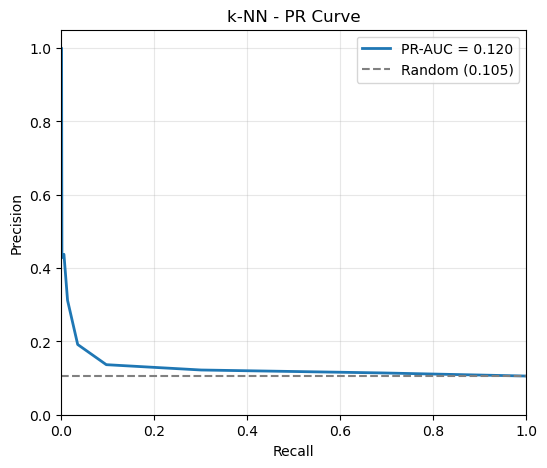

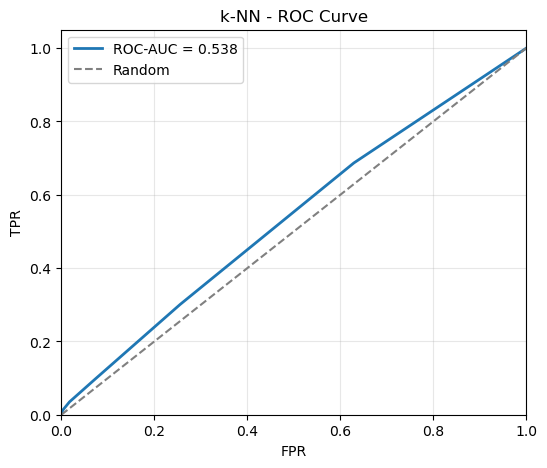

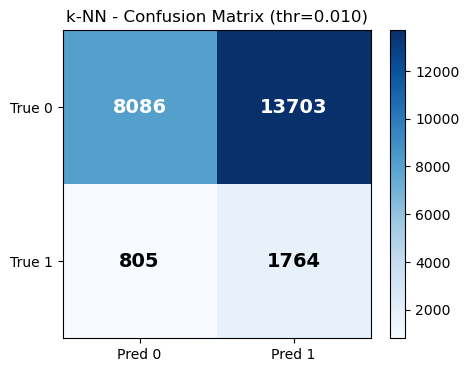

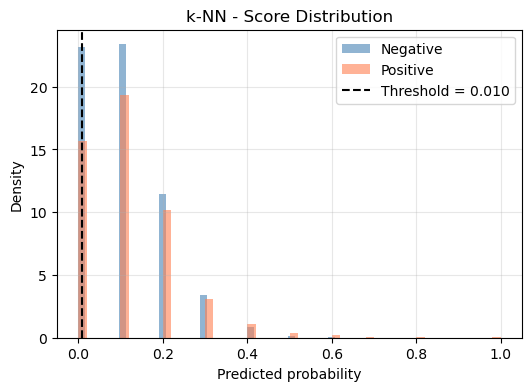

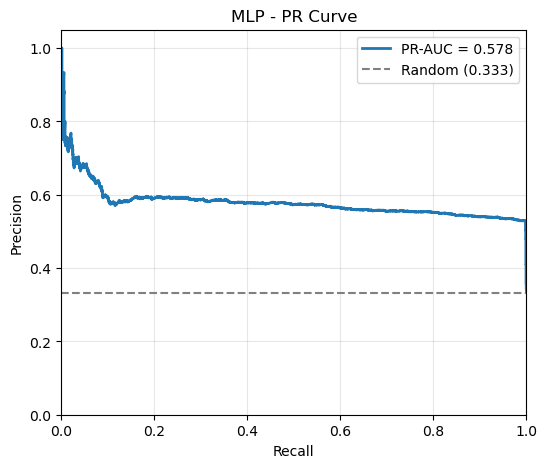

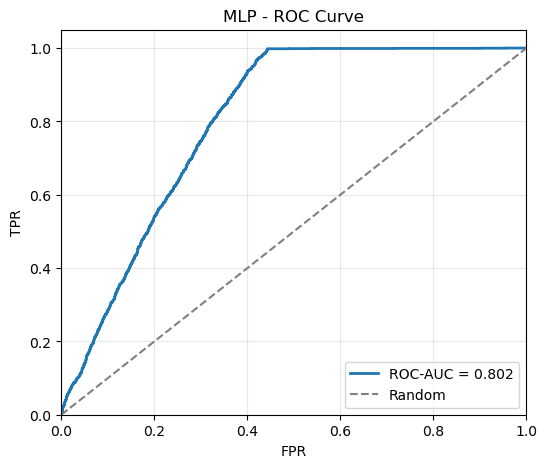

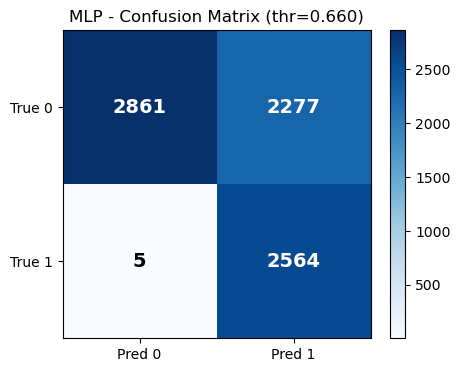

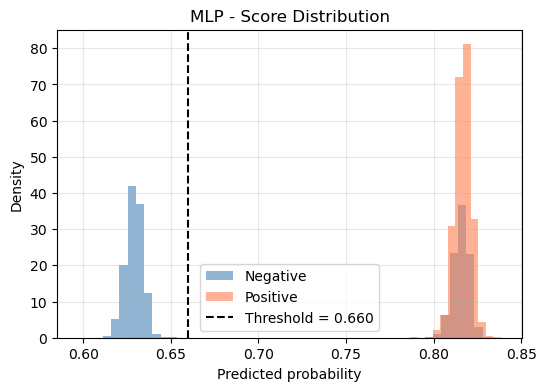

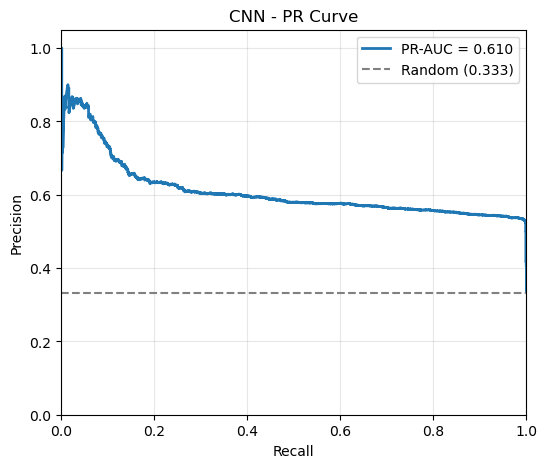

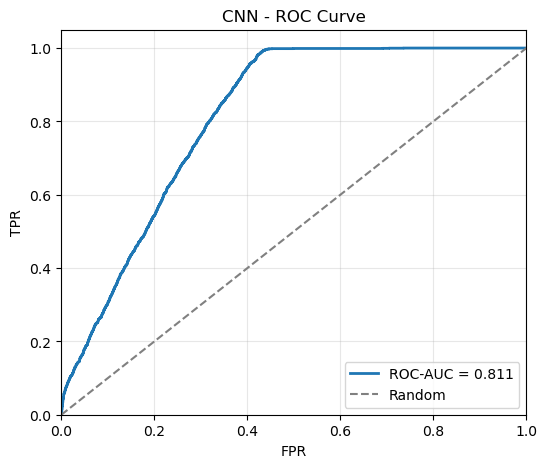

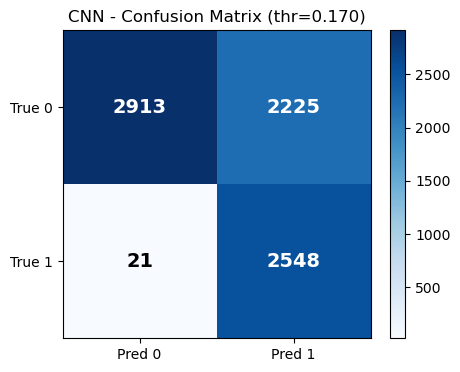

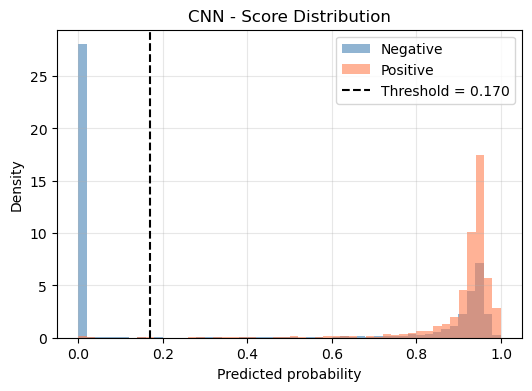

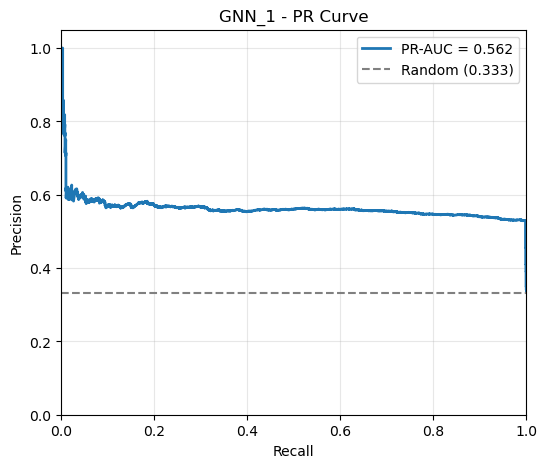

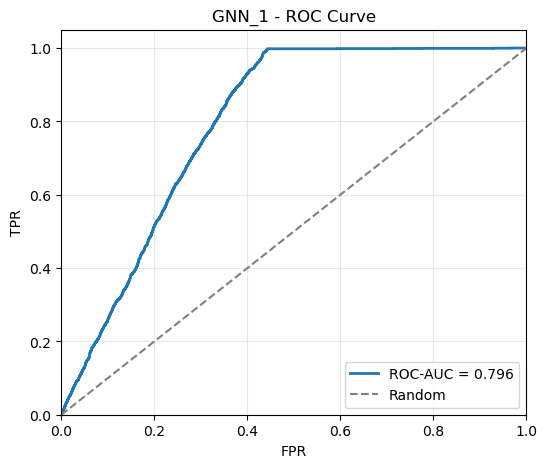

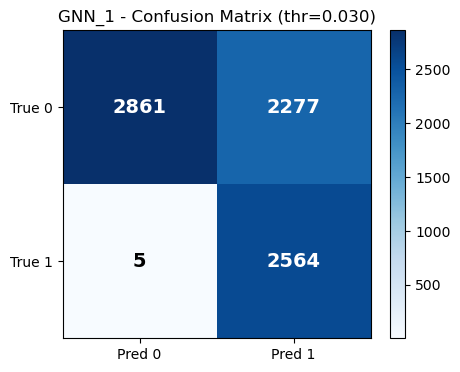

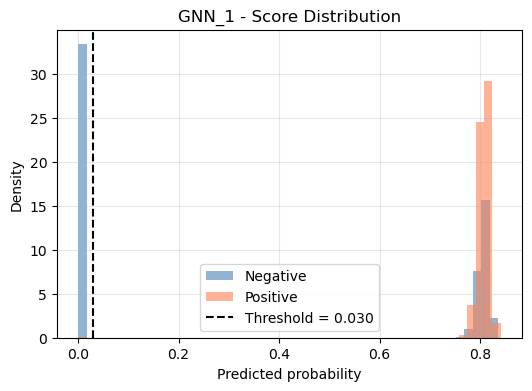

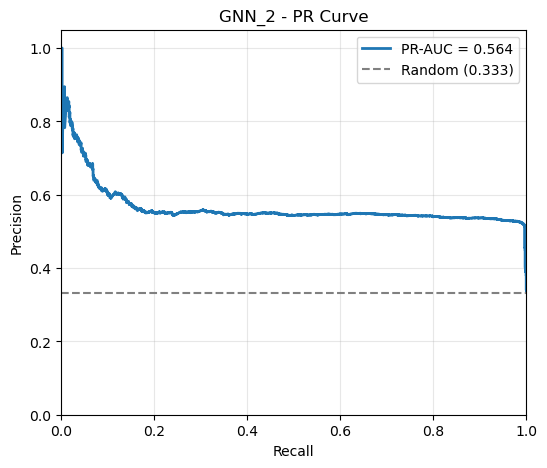

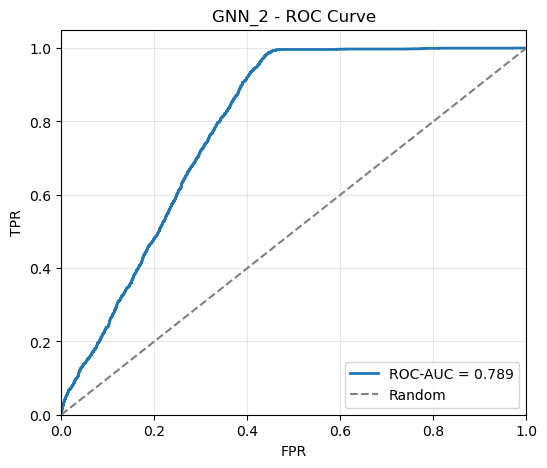

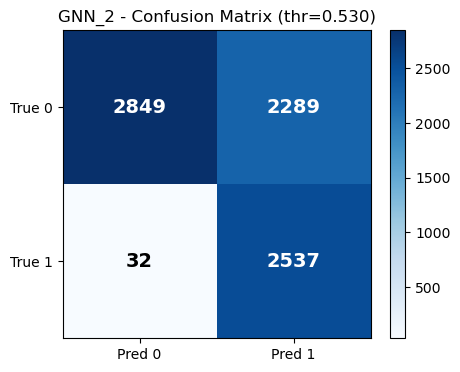

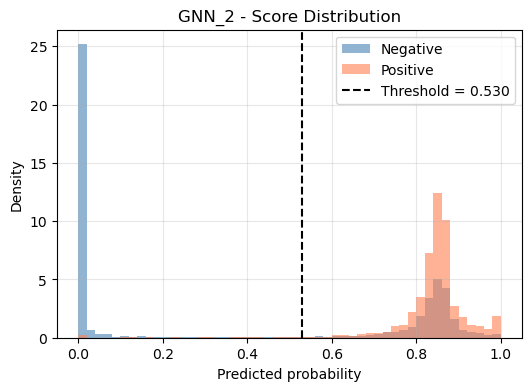

In [ ]:
p_test_knn = neigh.predict_proba(X_test)[:, 1]
p_val_knn = neigh.predict_proba(X_val)[:, 1]
results_knn = evaluate(y_test, p_test_knn, y_val, p_val_knn, model_name="k-NN", save_plots_dir="Wyniki_KNN")

# MLP/CNN/GNN (PyTorch)

y_test, p_test_mlp = predict(model_mlp_test, test_loader_mlp, device, step)
y_val, p_val_mlp = predict(model_mlp_test, val_loader_mlp, device, step)
results_mlp = evaluate(y_test, p_test_mlp, y_val, p_val_mlp, model_name="MLP", save_plots_dir="Wyniki_MLP")

y_test, p_test_cnn = predict(model_cnn_test, test_loader_cnn, device, step)
y_val, p_val_cnn = predict(model_cnn_test, val_loader_cnn, device, step)
results_cnn = evaluate(y_test, p_test_cnn, y_val, p_val_cnn, model_name="CNN", save_plots_dir="Wyniki_CNN")

y_test, p_test_gnn = predict(model_gnn1_test, test_loader_gnn, device, step)
y_val, p_val_gnn = predict(model_gnn1_test, val_loader_gnn, device, step)
results_gnn1 = evaluate(y_test, p_test_gnn, y_val, p_val_gnn, model_name="GNN_1", save_plots_dir="Wyniki_GNN")

y_test, p_test_gnn = predict(model_gnn2_test, test_loader_gnn, device, step)
y_val, p_val_gnn = predict(model_gnn2_test, val_loader_gnn, device, step)
results_gnn2 = evaluate(y_test, p_test_gnn, y_val, p_val_gnn, model_name="GNN_2", save_plots_dir="Wyniki_GNN")

In [ ]:
print(f"Wyniki Ewaluacji KNN: {results_knn}")
print(f"Wyniki Ewaluacji MLP: {results_mlp}")
print(f"Wyniki Ewaluacji CNN: {results_cnn}")
print(f"Wyniki Ewaluacji GNN: {results_gnn1}")
print(f"Wyniki Ewaluacji GNN: {results_gnn2}")

Wyniki Ewaluacji KNN: {'model_name': 'k-NN', 'n_test': 24358, 'n_positives': 2569, 'pos_fraction': 0.10546842926348633, 'baseline': 0.10546842926348633, 'pr_auc': (0.1196497962446236, np.float64(0.11399235699772671), np.float64(0.1261531162144726)), 'roc_auc': (0.5377652516819681, np.float64(0.5263976070208741), np.float64(0.5486032353432939)), 'hits_at_100': 0.012845465161541456, 'threshold': 0.01, 'f1': 0.19560878243512975, 'mcc': 0.03684667555006409, 'confusion_matrix': array([[ 8086, 13703],
       [  805,  1764]]), 'per_mhc': None, 'figures': {'pr_curve': <Figure size 600x500 with 1 Axes>, 'roc_curve': <Figure size 600x500 with 1 Axes>, 'confusion_matrix': <Figure size 500x400 with 2 Axes>, 'score_distribution': <Figure size 600x400 with 1 Axes>}}
Wyniki Ewaluacji MLP: {'model_name': 'MLP', 'n_test': 7707, 'n_positives': 2569, 'pos_fraction': 0.3333333333333333, 'baseline': 0.3333333333333333, 'pr_auc': (0.5784973160411666, np.float64(0.5579801688830485), np.float64(0.600786405466